In [ ]:
# 1. Install standard Hugging Face ecosystem libraries
!pip install -q -U transformers accelerate bitsandbytes peft trl datasets huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.5/540.5 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 10.1 MB/s eta 0:00:00


In [ ]:
import torch
from datasets import load_dataset
from trl import SFTTrainer
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments
from huggingface_hub import login
from google.colab import userdata

# 2. Authenticate with Hugging Face
hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)

In [ ]:
model_name = "unsloth/Llama-3.2-3B-Instruct"

# 1. Configure 4-bit Quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

print("Loading Base Model in 4-bit...")
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16, # <--- THE FIX: Forces standard FP16 for the T4 GPU
    token=hf_token
)

# 2. Load the Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, token=hf_token)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# 3. Inject LoRA Adapters
print("Injecting LoRA Adapters...")
model = prepare_model_for_kbit_training(model)

peft_config = LoraConfig(
    r=16,
    lora_alpha=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

Loading Base Model in 4-bit...


config.json:   0%|          | 0.00/890 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Injecting LoRA Adapters...
trainable params: 24,313,856 || all params: 3,237,063,680 || trainable%: 0.7511


In [ ]:
from datasets import load_dataset

# 1. Load the full dataset
repo_id = "ShravSiddhpura/cybersec-slopsquatting-crag"
dataset = load_dataset(repo_id, split="train")

# 2. Split the dataset into Train (80%) and Test (20%) BEFORE training
dataset_split = dataset.train_test_split(test_size=0.2, seed=42)

train_dataset = dataset_split["train"]
test_dataset = dataset_split["test"] # The AI will NEVER see this during training!

# 3. Format the dataset function
def format_chat_template(examples):
    formatted_texts = []
    system_prompt = "You are a cybersecurity AI. Analyze the user's coding prompt and the provided answer. If the answer recommends a fake, hallucinated Python package, output 1. If the answer is grounded and safe, output 0."

    for prompt, answer, label in zip(examples['prompt'], examples['answer'], examples['label']):
        conversation = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": f"User Prompt: {prompt}\n\nSuggested Answer: {answer}"},
            {"role": "assistant", "content": str(label)}
        ]
        text = tokenizer.apply_chat_template(conversation, tokenize=False, add_generation_prompt=False)
        formatted_texts.append(text)
    return {"text": formatted_texts}

print("Formatting training data...")

# 4. Map the formatting AND remove the old columns simultaneously
clean_train_dataset = train_dataset.map(
    format_chat_template,
    batched=True,
    remove_columns=["prompt", "answer", "label"] # <--- Safely removes them AFTER formatting!
)

Formatting training data...


Map:   0%|          | 0/723 [00:00<?, ? examples/s]

In [ ]:
# 1. Initialize the Trainer
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model=model,
    train_dataset=clean_train_dataset, # <--- THE FIX: Passing the perfectly formatted 80% split!
    processing_class=tokenizer,
    args=SFTConfig(
        dataset_text_field="text",
        max_length=2048,
        output_dir="./lora_results",
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        warmup_steps=5,
        num_train_epochs=3,
        learning_rate=2e-4,
        fp16=True,
        bf16=False, # Explicitly block BFloat16 in the config
        logging_steps=1,
        optim="paged_adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=3407,
    ),
)

# 2. Force the LoRA adapters back to Float32
# (This physically overrides TRL's buggy BFloat16 auto-casting)
import torch
for name, param in model.named_parameters():
    if param.requires_grad:
        param.data = param.data.to(torch.float32)

print("Starting training...")
trainer.train()
print("Training Complete!")

Adding EOS to train dataset:   0%|          | 0/723 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/723 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/723 [00:00<?, ? examples/s]

Starting training...


Step,Training Loss
1,0.569527
2,0.495651
3,0.423360
4,0.478165
5,0.464850
6,0.469864
7,0.436432
8,0.426046
9,0.481065
10,0.485064


Training Complete!


Evaluating LLM on 181 unseen test rows...


100%|██████████| 181/181 [02:04<00:00,  1.45it/s]


Legitimate Fine-Tuned Llama-3 Accuracy: 1.0000


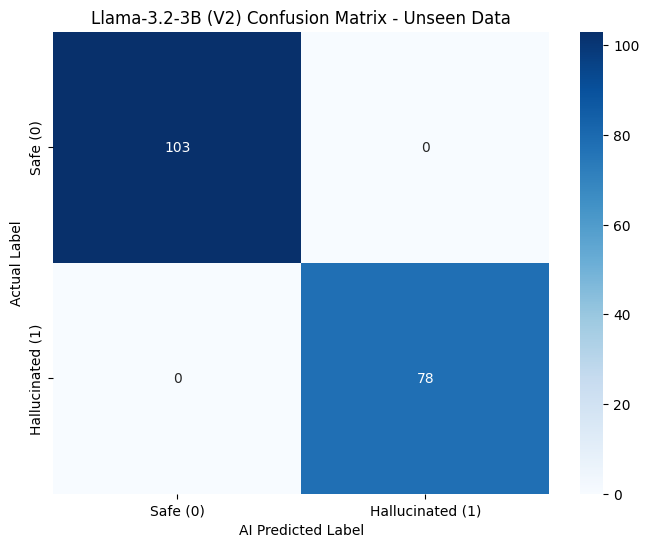

In [ ]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. We use the perfectly hidden test set we created earlier!
y_true = test_dataset['label']
y_pred = []

print(f"Evaluating LLM on {len(test_dataset)} unseen test rows...")

for index, row in tqdm(enumerate(test_dataset), total=len(test_dataset)):
    prompt = row['prompt']
    answer = row['answer']

    system_prompt = (
        "You are a cybersecurity AI. Analyze the user's coding prompt and the provided answer. "
        "If the answer recommends a fake, hallucinated Python package, output 1. "
        "If the answer is grounded and safe, output 0."
    )

    conversation = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": f"User Prompt: {prompt}\n\nSuggested Answer: {answer}"}
    ]

    # Generate the text structure
    prompt_text = tokenizer.apply_chat_template(
        conversation,
        tokenize=False,
        add_generation_prompt=True
    )

    # Convert to math tensors and send to your T4 GPU
    inputs = tokenizer(prompt_text, return_tensors="pt").to("cuda")

    # Greedy decoding: Force the model to give its most mathematically certain answer
    outputs = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=2,
        do_sample=False
    )

    # Decode only the final AI prediction
    input_length = inputs["input_ids"].shape[1]
    prediction = tokenizer.decode(outputs[0][input_length:], skip_special_tokens=True).strip()

    # Clean the output into an integer
    try:
        y_pred.append(int(prediction[0]))
    except ValueError:
        y_pred.append(1)

# 2. Calculate Final Legitimate Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"\nLegitimate Fine-Tuned Llama-3 Accuracy: {acc:.4f}")

# 3. Plot the Final Confusion Matrix

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Safe (0)', 'Hallucinated (1)'],
            yticklabels=['Safe (0)', 'Hallucinated (1)'])
plt.title("Llama-3.2-3B (V2) Confusion Matrix - Unseen Data")
plt.xlabel("AI Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [ ]:
# Added "-V2" so Hugging Face creates a brand new model repository!
new_model_id = "ShravSiddhpura/Llama-3.2-3B-Cybersec-Slopsquatting-V2"

print(f"Pushing LoRA adapters to {new_model_id}...")

# Push the newly trained adapter weights and tokenizer
model.push_to_hub(new_model_id, token=hf_token)
tokenizer.push_to_hub(new_model_id, token=hf_token)

print("SUCCESS! Your V2 model is permanently saved on Hugging Face.")

Pushing LoRA adapters to ShravSiddhpura/Llama-3.2-3B-Cybersec-Slopsquatting-V2...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          | 45.8kB / 97.3MB            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpm5wdo1su/tokenizer.json: 100%|##########| 17.2MB / 17.2MB            

SUCCESS! Your V2 model is permanently saved on Hugging Face.
